/tmp/ipykernel_17/3627883194.py:165: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


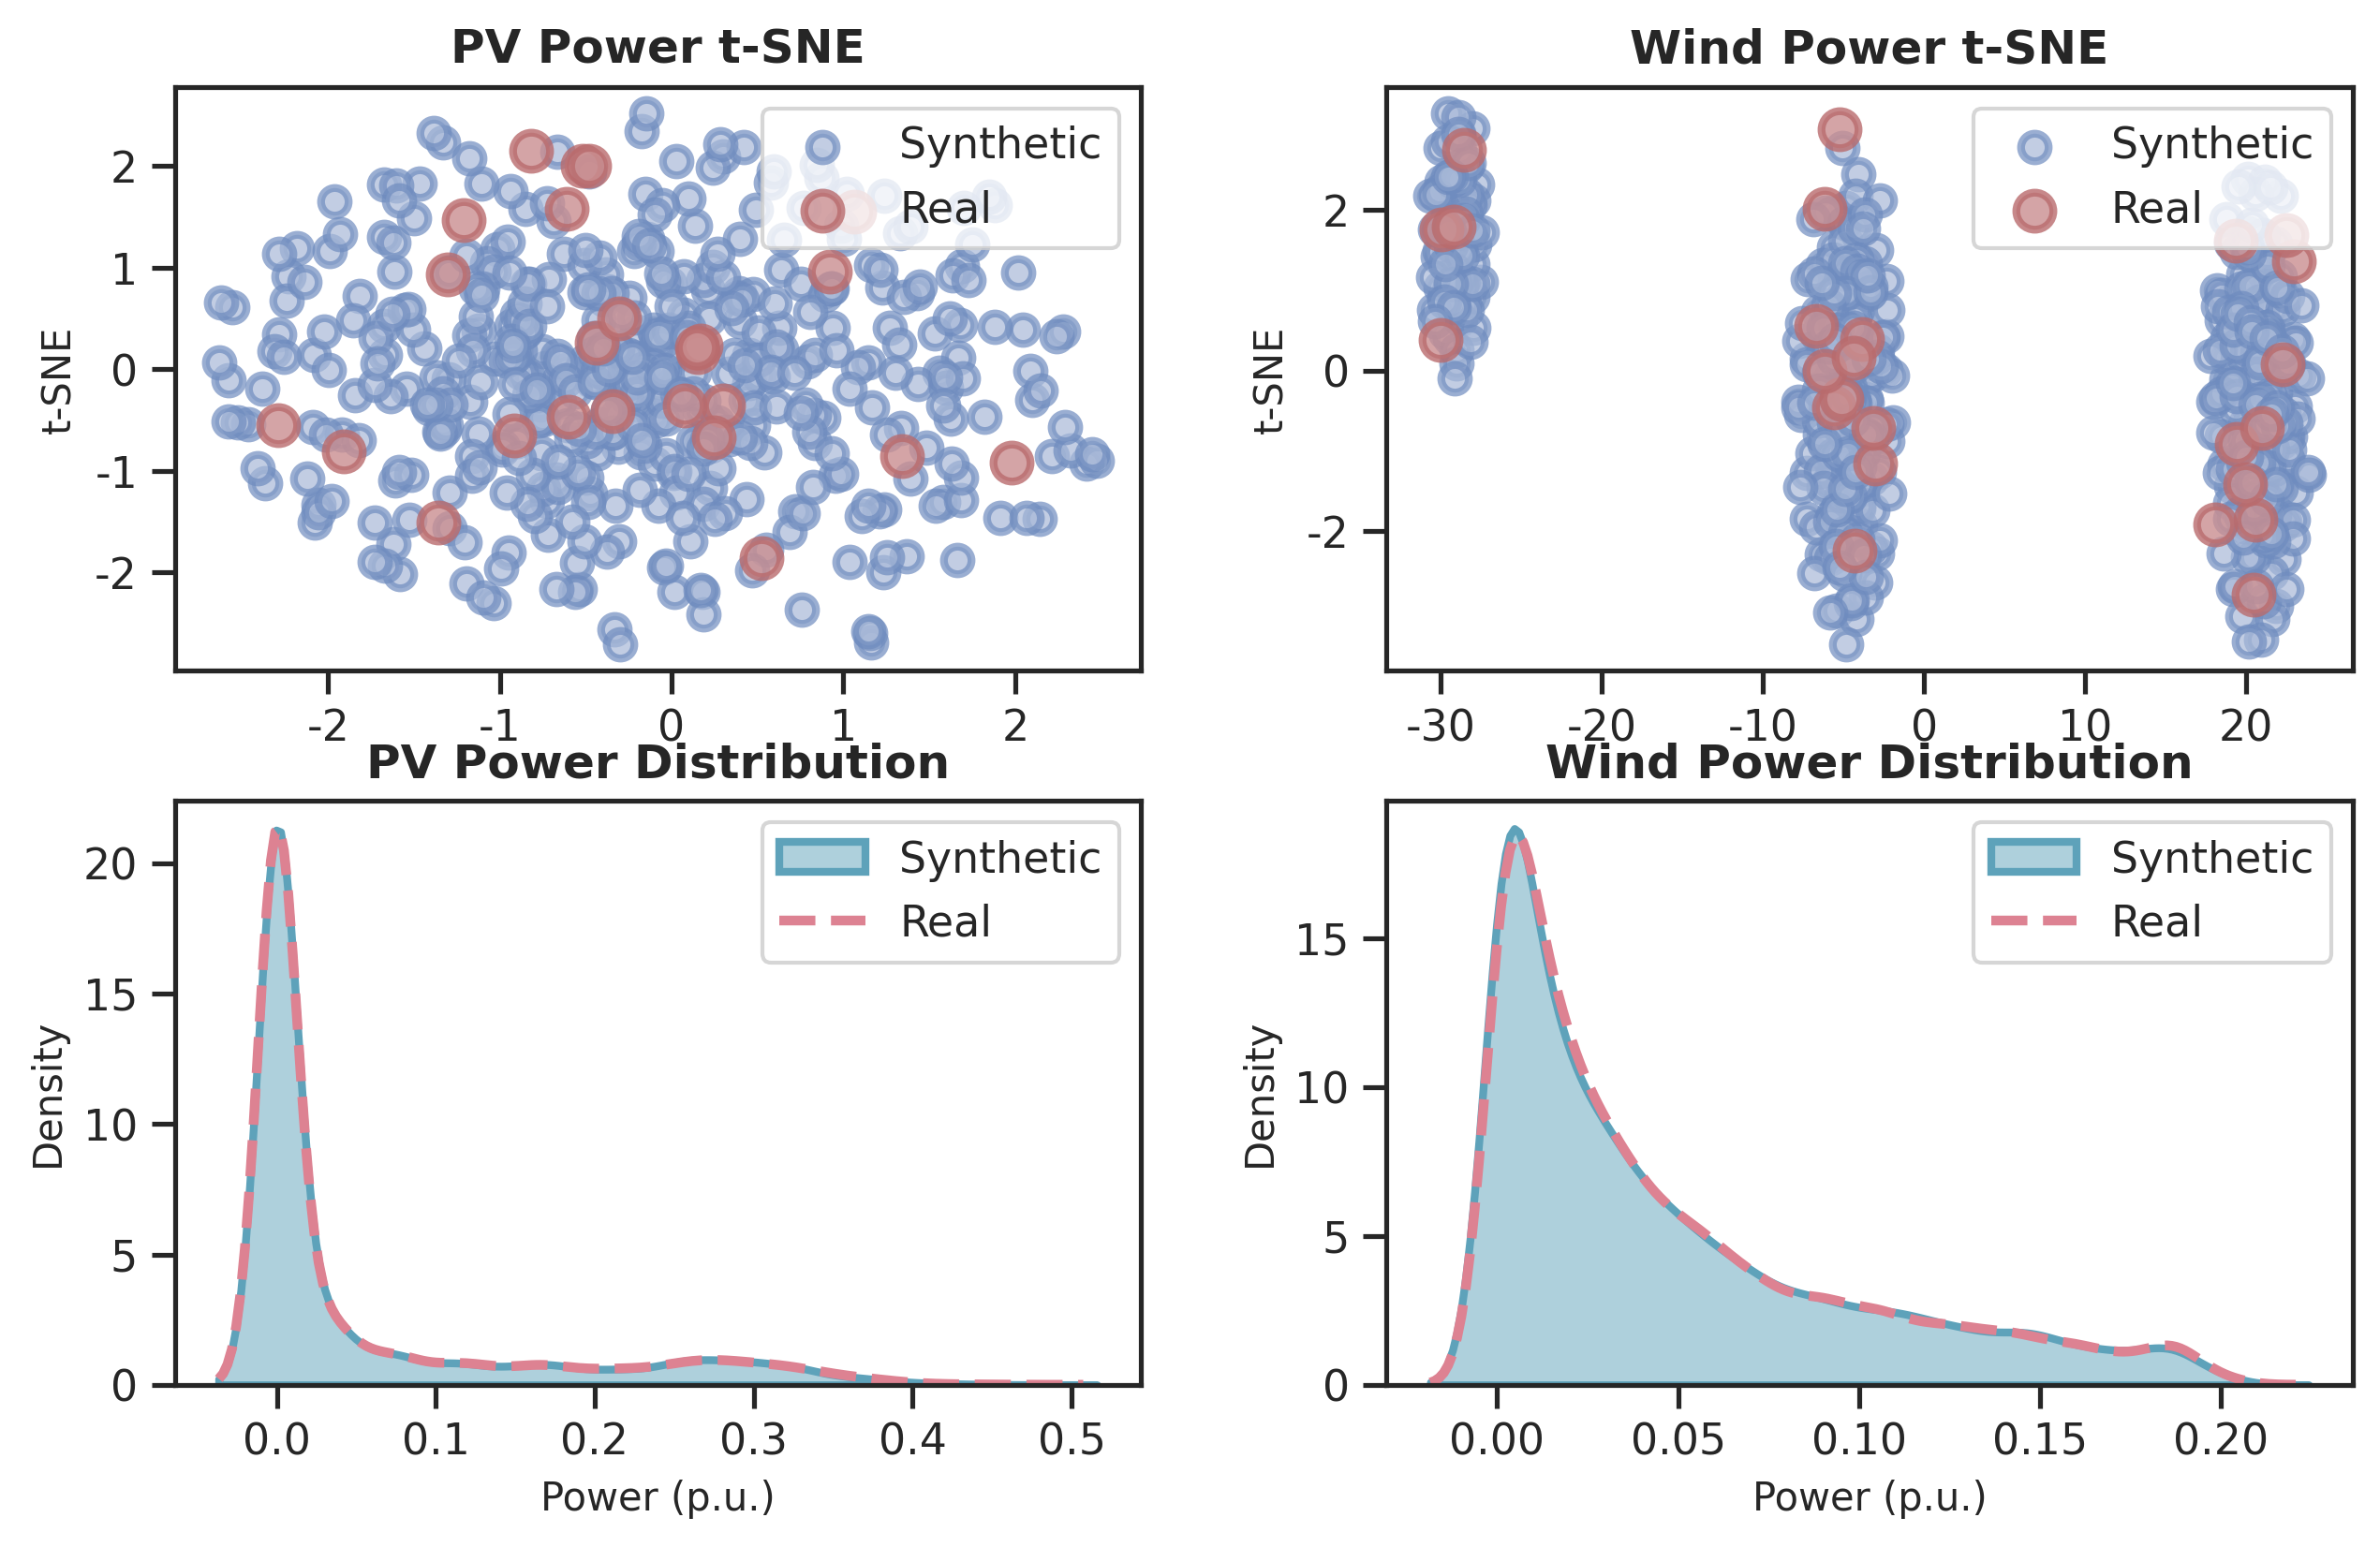

In [1]:
!pip install scienceplots
import matplotlib.pyplot as plt
import numpy as np
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
import pandas as pd
import scienceplots
import seaborn as sns
from datetime import datetime, timedelta
from matplotlib.ticker import MultipleLocator

plt.rcParams['savefig.dpi'] = 300
plt.rcParams['figure.dpi'] = 300
plt.rcParams['font.family']='Times New Roman'
plt.rcParams['axes.unicode_minus']= False
sns.set(style='ticks')
plt.style.use(sorted(plt.style.available)[31])

wind_series_500 = pd.read_csv(r"/kaggle/input/datasets/belovedorange/research-methodology-project/node_22_wind_actual.csv")
power_df = pd.read_csv(r"/kaggle/input/datasets/belovedorange/research-methodology-project/node_18_PV_actual.csv")



def plot_tsne_scatter(power_df, n_series=200, selection_method='random', random_state=42, data_type='auto'):
    np.random.seed(random_state)

    if data_type == 'auto':
        pv_columns = [col for col in power_df.columns if col.startswith('PV_power_')]
        wind_columns = [col for col in power_df.columns if col.startswith('wind_power_')]
        
        if len(pv_columns) > 0 and len(wind_columns) == 0:
            power_columns = pv_columns
            detected_type = 'PV'
        elif len(wind_columns) > 0 and len(pv_columns) == 0:
            power_columns = wind_columns
            detected_type = 'Wind'
        elif len(pv_columns) > 0 and len(wind_columns) > 0:
            if len(pv_columns) >= len(wind_columns):
                power_columns = pv_columns
                detected_type = 'PV'
            else:
                power_columns = wind_columns
                detected_type = 'Wind'
        else:
            raise ValueError("can not find selected columns")
        
    elif data_type == 'pv':
        power_columns = [col for col in power_df.columns if col.startswith('PV_power_')]
        
    else:
        power_columns = [col for col in power_df.columns if col.startswith('wind_power_')]

    n_synthetic = int(0.95 * n_series)
    n_real = n_series - n_synthetic

    if selection_method == 'random':
        selected_columns = np.random.choice(power_columns, n_series, replace=False)
        synthetic_columns = selected_columns[:n_synthetic]
        real_columns = selected_columns[n_synthetic:]
    if selection_method == 'sequential':
        synthetic_columns = power_columns[:n_synthetic]
        real_columns = power_columns[n_synthetic:n_synthetic + n_real]

    synthetic_data = power_df[synthetic_columns].T.values
    real_data = power_df[real_columns].T.values

    all_data = np.vstack([synthetic_data, real_data])

    labels = ['Synthetic'] * n_synthetic + ['Real'] * n_real

    scaler = StandardScaler()
    scaled_data = scaler.fit_transform(all_data)

    tsne = TSNE(n_components=2, random_state=random_state, perplexity=min(30, n_series//4))
    tsne_results = tsne.fit_transform(scaled_data)

    synthetic_tsne = tsne_results[:n_synthetic]
    real_tsne = tsne_results[n_synthetic:]
    
    return synthetic_tsne, real_tsne




fig = plt.figure(figsize=(10, 6))
grid = plt.GridSpec(20, 20, wspace=0.3, hspace=0)

ax1 = fig.add_subplot(grid[:9, :9])      # solar t-SNE
ax11 = fig.add_subplot(grid[11:, :9])    # solar KDE
ax2 = fig.add_subplot(grid[:9, 11:])     # wind t-SNE
ax22 = fig.add_subplot(grid[11:, 11:])   # wind KDE

synthetic_tsne_pv, real_tsne_pv = plot_tsne_scatter(
    power_df, 
    n_series=500, 
    selection_method='random',
    random_state=42
)

ax1.scatter(synthetic_tsne_pv[:, 0], synthetic_tsne_pv[:, 1], 
            facecolors='#A8B9D8',
            edgecolors='#6F8CBF',
            s=50, alpha=0.7, zorder=1, linewidths=2, label='Synthetic')

ax1.scatter(real_tsne_pv[:, 0], real_tsne_pv[:, 1], 
            facecolors='#CA8E90',
            edgecolors='#B96B6D',
            s=90, alpha=0.8, zorder=2, linewidths=2, label='Real')

ax1.set_title('PV Power t-SNE', fontsize=12, fontweight='bold')
ax1.set_ylabel('t-SNE', fontsize=10)
ax1.legend(loc='upper right')


ori_data_pv = np.array(power_df.iloc[:, 1])
fake_data_pv = np.array(power_df.iloc[:, 3])

sns.kdeplot(ori_data_pv, ax=ax11, linewidth=2, color="#5EA2BA", 
            fill=True, alpha=0.5, label='Synthetic')
sns.kdeplot(fake_data_pv, ax=ax11, linewidth=2.5, linestyle='--', 
            color="#DD8292", label='Real')

ax11.set_title('PV Power Distribution', fontsize=12, fontweight='bold')
ax11.set_xlabel('Power (p.u.)', fontsize=10)
ax11.set_ylabel('Density', fontsize=10)
ax11.legend()



synthetic_tsne_wind, real_tsne_wind = plot_tsne_scatter(
    wind_series_500, 
    n_series=500, 
    selection_method='random',
    random_state=42
)

ax2.scatter(synthetic_tsne_wind[:, 0], synthetic_tsne_wind[:, 1], 
            facecolors='#A8B9D8',
            edgecolors='#6F8CBF',
            s=50, alpha=0.7, zorder=1, linewidths=2, label='Synthetic')

ax2.scatter(real_tsne_wind[:, 0], real_tsne_wind[:, 1], 
            facecolors='#CA8E90',
            edgecolors='#B96B6D',
            s=90, alpha=0.8, zorder=2, linewidths=2, label='Real')

ax2.set_title('Wind Power t-SNE', fontsize=12, fontweight='bold')
ax2.set_ylabel('t-SNE', fontsize=10)
ax2.legend(loc='upper right')


ori_data_wind = np.array(wind_series_500.iloc[:,1])
fake_data_wind = np.array(wind_series_500.iloc[:,3])

sns.kdeplot(ori_data_wind, ax=ax22, linewidth=2, color="#5EA2BA", 
            fill=True, alpha=0.5, label='Synthetic')
sns.kdeplot(fake_data_wind, ax=ax22, linewidth=2.5, linestyle='--', 
            color="#DD8292", label='Real')

ax22.set_title('Wind Power Distribution', fontsize=12, fontweight='bold')
ax22.set_xlabel('Power (p.u.)', fontsize=10)
ax22.set_ylabel('Density', fontsize=10)
ax22.legend()

plt.tight_layout()
plt.show()